#### FUTURE_DS_03 : Key Insights & Business Recommendations

Ce notebook vient conclure notre analyse de l'entonnoir marketing (Funnel Analysis).
Nous synthétisons ici les découvertes majeures et proposons des axes d'optimisation clairs pour les futures campagnes de télémarketing de la banque.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Configuration du chemin
src_path = Path.cwd().parent / 'src'
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from utils import setup_logger
from funnel_analysis_functions import get_funnel_stages
from funnel_metrics import calculate_funnel_metrics

# Chargement des données
df_clean = pd.read_csv(Path.cwd().parent / 'data/processed/bank-marketing_cleaned.csv', sep=';')
stages = get_funnel_stages(df_clean)
metrics = calculate_funnel_metrics(df_clean, stages)

print("✅ Données chargées et métriques prêtes pour le résumé exécutif.")

✅ Données chargées et métriques prêtes pour le résumé exécutif.


- Chargement des données

In [ ]:
DATA_PATH = str(Path.cwd().parent / "data/processed/bank-marketing_cleaned.csv")
df = pd.read_csv(DATA_PATH, sep=';')

print(f"✅ Données chargées : {df.shape[0]:,} contacts")
print(f"📊 Taux de conversion global : {df['converted'].mean()*100:.2f}%")

✅ Données chargées : 775 contacts
📊 Taux de conversion global : 22.32%


- Calcul des métriques globales

In [ ]:
stages = get_funnel_stages(df)
metrics = calculate_funnel_metrics(df, stages)

print("=" * 50)
print("📊 PERFORMANCE GLOBALE DU FUNNEL")
print("=" * 50)
print(f"\n🎯 Impressions totales : {stages['Impressions']:,}")
print(f"📞 Contacts établis   : {stages['Contacted']:,} ({metrics['contact_rate']:.1f}%)")
print(f"💬 Contacts engagés   : {stages['Engaged']:,} ({metrics['engagement_rate']:.1f}%)")
print(f"✅ Conversions totales : {stages['Converted']:,} ({metrics['conversion_rate']:.1f}%)")

📊 PERFORMANCE GLOBALE DU FUNNEL

🎯 Impressions totales : 775
📞 Contacts établis   : 775 (100.0%)
💬 Contacts engagés   : 694 (89.5%)
✅ Conversions totales : 173 (22.3%)


- Points de friction (Drop-offs)

In [ ]:
print("=" * 50)
print("⚠️ POINTS DE FRICTION")
print("=" * 50)

dropoff_contact = ((stages['Impressions'] - stages['Contacted']) / stages['Impressions']) * 100
dropoff_engaged = ((stages['Contacted'] - stages['Engaged']) / stages['Contacted']) * 100
dropoff_converted = ((stages['Engaged'] - stages['Converted']) / stages['Engaged']) * 100

print(f"\n❌ Non-décrochés    : {dropoff_contact:.1f}% des impressions")
print(f"❌ Non-engagés      : {dropoff_engaged:.1f}% des contacts")
print(f"❌ Non-convertis    : {dropoff_converted:.1f}% des engagés")

⚠️ POINTS DE FRICTION

❌ Non-décrochés    : 0.0% des impressions
❌ Non-engagés      : 10.5% des contacts
❌ Non-convertis    : 75.1% des engagés


- Top segments performants (Profession)

C:\Users\OMEN 16\AppData\Local\Temp\ipykernel_19340\871490009.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_jobs.index, x=top_jobs['mean'] * 100, palette='viridis')


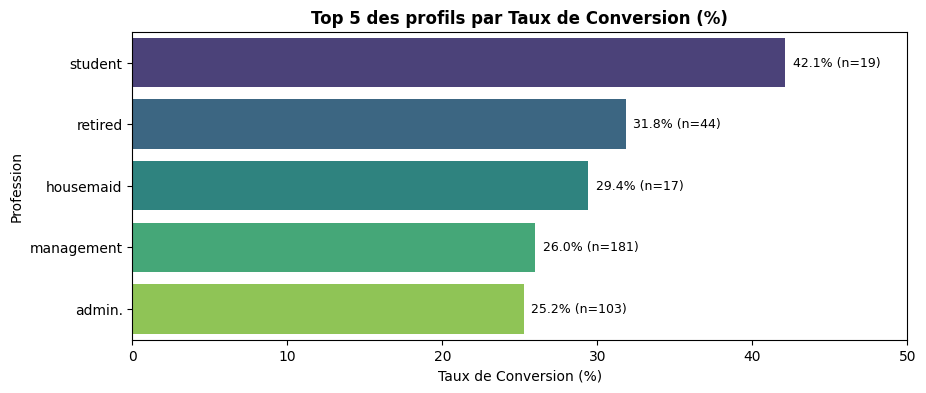

In [ ]:
# Résumé graphique des top audiences
plt.figure(figsize=(10, 4))
top_jobs = df_clean.groupby('job')['converted'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(5)
sns.barplot(y=top_jobs.index, x=top_jobs['mean'] * 100, palette='viridis')
plt.title('Top 5 des profils par Taux de Conversion (%)', fontweight='bold')
plt.xlabel('Taux de Conversion (%)')
plt.ylabel('Profession')
for i, (val, count) in enumerate(zip(top_jobs['mean'] * 100, top_jobs['count'])):
    plt.text(val + 0.5, i, f'{val:.1f}% (n={count})', va='center', fontsize=9)
plt.xlim(0, 50)
plt.show()

les professionnels établis ne sont pas les plus enclins à souscrire.
- 🥇 **Les Étudiants(student) `(42.1%)`**
- 🥈 **Les Retraités(retired) `(31.8%)`**

Ces deux groupes, bien qu'ayant un volume de prospects beaucoup plus faible actuellement, présentent les **taux de conversion les plus élevés**, écrasant la moyenne de 22.3%. 

En parallèle, les profils de **Management** (26.0%) assurent un compromis idéal entre fort volume et très bon taux de conversion.

- Top segments performants (Canal de contact)

In [ ]:
print("=" * 50)
print("📱 PERFORMANCE PAR CANAL")
print("=" * 50)

contact_conv = calculate_conversion_by_dimension(df, 'contact', top_n=3)

for _, row in contact_conv.iterrows():
    contact = row['contact'] if pd.notna(row['contact']) else 'Unknown'
    rate = row['conversion_rate']
    count = int(row['total_contacts'])
    print(f"  {contact:20s} : {rate:5.1f}% (n={count})")

📱 PERFORMANCE PAR CANAL
  telephone            :  22.4% (n=67)
  cellular             :  22.4% (n=697)
  unknown              :  18.2% (n=11)


- Top segments performants (Mois)

In [ ]:
print("=" * 50)
print("📅 TOP 5 MOIS (Taux de conversion)")
print("=" * 50)

month_conv = calculate_conversion_by_dimension(df, 'month', top_n=5)

for _, row in month_conv.iterrows():
    month = row['month'] if pd.notna(row['month']) else 'Unknown'
    rate = row['conversion_rate']
    count = int(row['total_contacts'])
    print(f"  {month:20s} : {rate:5.1f}% (n={count})")

📅 TOP 5 MOIS (Taux de conversion)
  dec                  :  58.3% (n=12)
  aug                  :  52.2% (n=46)
  oct                  :  50.0% (n=30)
  jun                  :  48.1% (n=27)
  sep                  :  47.8% (n=23)


- Impact de la durée d'appel

In [ ]:
print("=" * 50)
print("⏱️ IMPACT DE LA DURÉE D'APPEL")
print("=" * 50)

avg_duration_converted = df[df['converted'] == 1]['duration'].mean()
avg_duration_not_converted = df[df['converted'] == 0]['duration'].mean()

print(f"\n  Durée moyenne (convertis)     : {avg_duration_converted:.0f} sec")
print(f"  Durée moyenne (non-convertis) : {avg_duration_not_converted:.0f} sec")
print(f"  Différence                    : +{avg_duration_converted - avg_duration_not_converted:.0f} sec")

⏱️ IMPACT DE LA DURÉE D'APPEL

  Durée moyenne (convertis)     : 431 sec
  Durée moyenne (non-convertis) : 225 sec
  Différence                    : +205 sec



- RECOMMANDATIONS STRATÉGIQUES


📋 ACTIONS PAR SEGMENT :
   1. Prioriser le canal cellulaire (meilleure performance)
   2. Cibler les professions à fort taux de conversion
   3. Intensifier les campagnes sur les mois performants
   4. Viser une durée d'appel >180s pour maximiser la conversio